In [1]:
# data was downloaded from https://depmap.org/portal/

# U2OS is ACH-000364

# SKMEL1 is ACH-000465
# SKMEL2 is ACH-001190
# SKMEL3 is ACH-000423
# SKMEL5 is ACH-000730
# SKMEL19 is ACH-002005
# SKMEL24 is ACH-000822
# SKMEL28 is ACH-000615
# SKMEL30 is ACH-000810
# SKMEL31 is ACH-000640

# NP3 is ACH-001214
# T98G is ACH-000571
# U87MG is ACH-000075

In [ ]:
# run with all cell lines. 
# what are the different genes in one vs the other, that is the intesect of their uniqueness with skmel28
# check the proteomics.
# do log2 fc and p value for all cell lines. and then intersect of u2os and skmel of biomarkers.

# pca umap of all 
# intersect of particular biomarkers

In [2]:
import pandas, numpy

In [3]:
import scipy, scipy.signal, scipy.stats, scipy.stats
import sklearn, sklearn.preprocessing, sklearn.decomposition
import statsmodels, statsmodels.stats, statsmodels.stats.multitest

In [4]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })


In [5]:
# user-defined variables

In [6]:
expression_file = '/Users/adrian/research/025_isafjordur/data/mRNA/OmicsExpressionProteinCodingGenesTPMLogp1.csv'

In [7]:
working_cell_lines = ['ACH-000364', 
                      'ACH-000465', 'ACH-001190', 'ACH-000423', 'ACH-000730', 'ACH-002005', 'ACH-000822', 'ACH-000615', 'ACH-000810', 'ACH-000640',
                      'ACH-000504', 'ACH-000571', 'ACH-000075']

cell_line_names_map = {}

cell_line_names_map['ACH-000364'] = 'U2OS'

cell_line_names_map['ACH-000465'] = 'SKMEL1'
cell_line_names_map['ACH-001190'] = 'SKMEL2'
cell_line_names_map['ACH-000423'] = 'SKMEL3'
cell_line_names_map['ACH-000730'] = 'SKMEL5'
cell_line_names_map['ACH-002005'] = 'SKMEL19'
cell_line_names_map['ACH-000822'] = 'SKMEL24'
cell_line_names_map['ACH-000615'] = 'SKMEL28'
cell_line_names_map['ACH-000810'] = 'SKMEL30'
cell_line_names_map['ACH-000640'] = 'SKMEL31'

cell_line_names_map['ACH-000504'] = 'SNB75'
cell_line_names_map['ACH-000571'] = 'T98G'
cell_line_names_map['ACH-000075'] = 'U87MG'

In [8]:
df = pandas.read_csv(expression_file, sep=',', index_col=0)
print(df.shape)
df

(1673, 19193)


,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,H3C2 (8358),H3C3 (8352),AC098582.1 (8916),DUS4L-BCAP29 (115253422),C8orf44-SGK3 (100533105),ELOA3B (728929),NPBWR1 (2831),ELOA3D (100506888),ELOA3 (162699),CDR1 (1038)
ACH-001113,4.331992,0.000000,7.364660,2.792855,4.471187,0.028569,1.226509,3.044394,6.500005,4.739848,...,2.689299,0.189034,0.201634,2.130931,0.555816,0.000000,0.275007,0.0,0.000000,0.000000
ACH-001289,4.567424,0.584963,7.106641,2.543496,3.504620,0.000000,0.189034,3.813525,4.221877,3.481557,...,1.286881,1.049631,0.321928,1.464668,0.632268,0.000000,0.014355,0.0,0.000000,0.000000
ACH-001339,3.150560,0.000000,7.379118,2.333424,4.228049,0.056584,1.310340,6.687201,3.682573,3.273516,...,0.594549,1.097611,0.831877,2.946731,0.475085,0.000000,0.084064,0.0,0.000000,0.042644
ACH-001979,4.240314,0.000000,5.681168,2.063503,1.641546,0.000000,7.236301,5.948367,4.596935,2.918386,...,0.000000,0.000000,0.847997,1.887525,0.176323,0.000000,0.000000,0.0,0.000000,0.000000
ACH-002438,4.032101,0.000000,6.674687,2.117695,3.003602,0.000000,2.169925,6.838195,3.253989,4.276497,...,0.238787,0.378512,0.584963,1.748461,0.839960,0.000000,0.014355,0.0,0.000000,0.042644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000285,0.056584,0.000000,6.604368,3.266037,4.973152,0.411426,0.097611,0.704872,4.829850,5.178715,...,2.229588,0.084064,1.310340,3.039138,0.344828,0.000000,0.000000,0.0,0.475085,0.042644
ACH-002669,3.111031,0.000000,7.031329,1.541019,3.664483,0.014355,3.624101,6.805421,4.472488,4.397118,...,0.189034,0.400538,0.356144,1.327687,0.000000,0.000000,0.014355,0.0,0.000000,0.000000
ACH-001858,4.390943,0.000000,7.013239,1.887525,3.252476,0.028569,3.286881,6.902194,5.410748,3.401903,...,1.097611,0.400538,0.613532,1.992768,0.704872,0.000000,1.464668,0.0,0.000000,0.526069
ACH-001997,5.057450,0.000000,7.815191,2.538538,3.893362,0.028569,4.079805,6.971659,4.469886,3.463361,...,0.831877,0.847997,1.292782,2.153805,0.687061,0.000000,0.000000,0.0,0.000000,0.000000


In [9]:
wdf = df.loc[working_cell_lines, :]
print(wdf.shape)
wdf

(13, 19193)


,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,H3C2 (8358),H3C3 (8352),AC098582.1 (8916),DUS4L-BCAP29 (115253422),C8orf44-SGK3 (100533105),ELOA3B (728929),NPBWR1 (2831),ELOA3D (100506888),ELOA3 (162699),CDR1 (1038)
ACH-000364,4.519164,0.000000,6.673698,2.134221,4.107688,0.014355,0.422233,5.758889,4.806324,4.966707,...,2.503349,0.000000,0.863938,2.157044,0.000000,0.000000,0.505891,0.000000,0.389567,0.097611
ACH-000465,3.656496,0.000000,6.244316,2.518535,3.646163,0.298658,0.275007,5.329841,4.502712,5.094658,...,0.226509,0.516015,1.124328,2.572890,0.042644,0.000000,0.014355,0.163499,0.000000,0.000000
ACH-001190,4.002703,0.056584,7.097716,2.718088,4.610582,0.028569,2.490570,5.968321,4.426265,3.759156,...,0.799087,1.316146,0.298658,2.754888,0.124328,0.000000,0.344828,0.000000,0.000000,0.000000
ACH-000423,3.707083,0.000000,7.598797,2.350497,4.341274,0.014355,3.849999,5.711495,3.940167,4.294253,...,0.084064,0.516015,0.475085,3.707083,0.056584,0.356144,0.056584,0.226509,0.000000,0.000000
ACH-000730,3.877744,0.000000,6.580748,1.739848,3.824768,0.028569,0.475085,5.199280,4.333424,3.469886,...,2.298658,1.709291,0.310340,2.935460,0.475085,0.000000,0.000000,0.014355,0.000000,0.000000
ACH-002005,3.904002,0.000000,7.257576,2.341986,3.534809,0.070389,0.000000,4.682011,4.215679,3.232661,...,0.847997,0.641546,1.238787,2.843984,0.176323,0.000000,0.000000,0.000000,0.000000,0.000000
ACH-000822,3.854993,0.000000,5.883376,2.090853,3.367371,0.056584,3.044394,6.045705,3.628774,4.267536,...,0.150560,0.632268,0.933573,2.395063,0.298658,0.000000,0.176323,0.000000,0.000000,0.070389
ACH-000615,3.364572,0.000000,6.627753,1.956057,3.880686,0.097611,0.475085,6.021480,3.939227,3.757023,...,0.422233,1.077243,0.250962,1.831877,0.201634,0.000000,0.056584,0.000000,0.000000,0.000000
ACH-000810,3.350497,0.000000,6.390599,2.395063,4.472488,0.028569,0.226509,6.032542,4.230357,4.624101,...,0.970854,0.641546,0.432959,2.980025,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ACH-000640,4.006298,0.000000,6.499049,1.669027,3.221877,0.028569,4.143230,6.247548,3.612352,4.105175,...,0.344828,1.028569,0.831877,4.171527,0.286881,0.056584,0.475085,0.000000,0.000000,0.014355


In [10]:
expression = wdf.T
expression

,ACH-000364,ACH-000465,ACH-001190,ACH-000423,ACH-000730,ACH-002005,ACH-000822,ACH-000615,ACH-000810,ACH-000640,ACH-000504,ACH-000571,ACH-000075
TSPAN6 (7105),4.519164,3.656496,4.002703,3.707083,3.877744,3.904002,3.854993,3.364572,3.350497,4.006298,3.676944,2.737687,3.244887
TNMD (64102),0.000000,0.000000,0.056584,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.111031,0.000000,0.000000
DPM1 (8813),6.673698,6.244316,7.097716,7.598797,6.580748,7.257576,5.883376,6.627753,6.390599,6.499049,6.646019,6.742949,7.124535
SCYL3 (57147),2.134221,2.518535,2.718088,2.350497,1.739848,2.341986,2.090853,1.956057,2.395063,1.669027,2.446256,2.304511,1.933573
C1orf112 (55732),4.107688,3.646163,4.610582,4.341274,3.824768,3.534809,3.367371,3.880686,4.472488,3.221877,4.144046,3.716991,3.493135
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ELOA3B (728929),0.000000,0.000000,0.000000,0.356144,0.000000,0.000000,0.000000,0.000000,0.000000,0.056584,0.000000,0.000000,0.000000
NPBWR1 (2831),0.505891,0.014355,0.344828,0.056584,0.000000,0.000000,0.176323,0.056584,0.000000,0.475085,0.056584,0.028569,0.028569
ELOA3D (100506888),0.000000,0.163499,0.000000,0.226509,0.014355,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ELOA3 (162699),0.389567,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.070389,0.000000


170
16.746632406521094


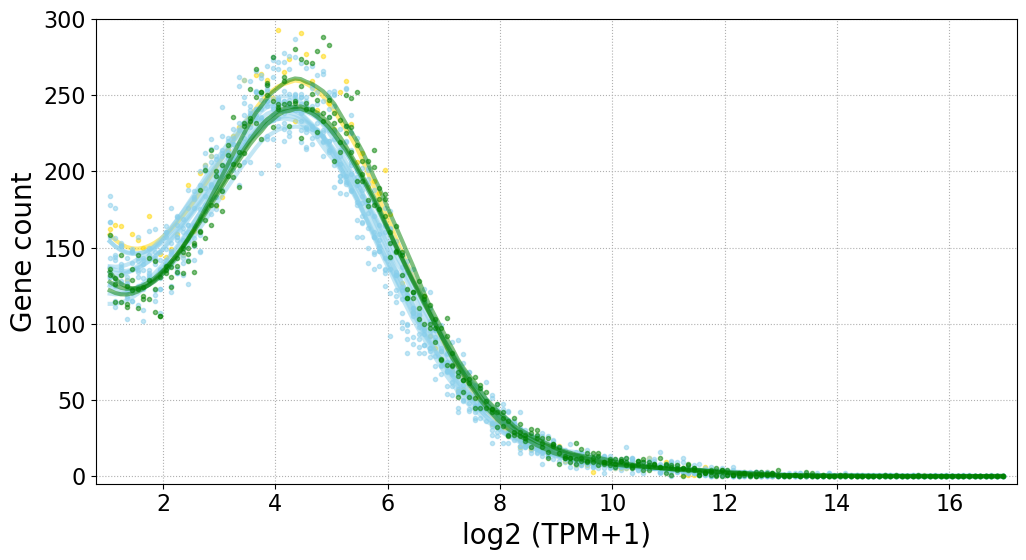

In [11]:
found_max = 17
number_of_bins = found_max*10
print(number_of_bins)

absolute_max = 0
working_samples = expression.columns.to_list()

for sample in working_samples:

    if sample == 'ACH-000364':
        the_color = 'gold'
    elif sample in ['ACH-000504', 'ACH-000571', 'ACH-000075']:
        the_color = 'green'
    else:
        the_color = 'skyblue'
    
    log2TPM = expression.loc[:, sample]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
       
    plotting_x = x[10:]
    plotting_hist = hist[10:]
    
    matplotlib.pyplot.plot(plotting_x, plotting_hist, '.', alpha=1/2, color=the_color)
    
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)
    
    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=3, alpha=1/2, color=the_color)
        
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])
matplotlib.pyplot.ylim([-5, 300])

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)

In [12]:
# detect top expressed 

In [13]:
substantial_expression = expression[expression.max(axis=1) >= numpy.log2(2+1)]
high_expression = expression[expression.max(axis=1) >= numpy.log2(100+1)]

print(substantial_expression.shape)
print(high_expression.shape)

(14127, 13)
(2947, 13)


In [14]:
pca_substantial_expression = substantial_expression.transpose()
pca_high_expression = high_expression.transpose()

[0.18419305 0.14190734]


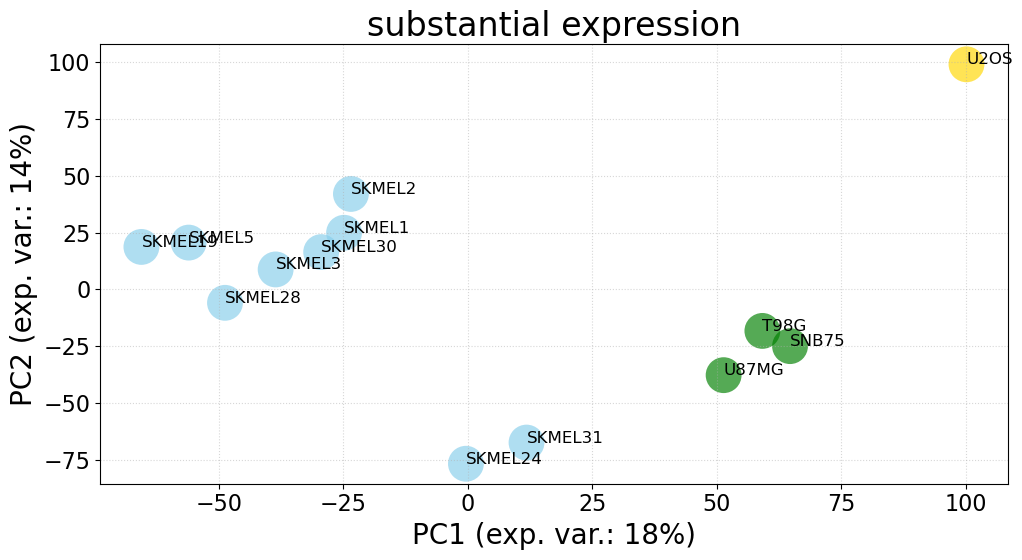

In [15]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

for i in range(len(new)):
    if i == 0:
        the_color = 'gold'
    elif i in [12, 11, 10]:
        the_color = 'green'
    else:
        the_color = 'skyblue'

    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    matplotlib.pyplot.text(new[i,0], new[i,1], cell_line_names_map[expression.columns[i]], fontsize=12)
    #matplotlib.pyplot.text(new[i,0], new[i,1], expression.columns[i], fontsize=12)

matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.title('substantial expression')
matplotlib.pyplot.grid(alpha=0.5, ls=':')
matplotlib.pyplot.tight_layout()

[0.20165682 0.1498388 ]


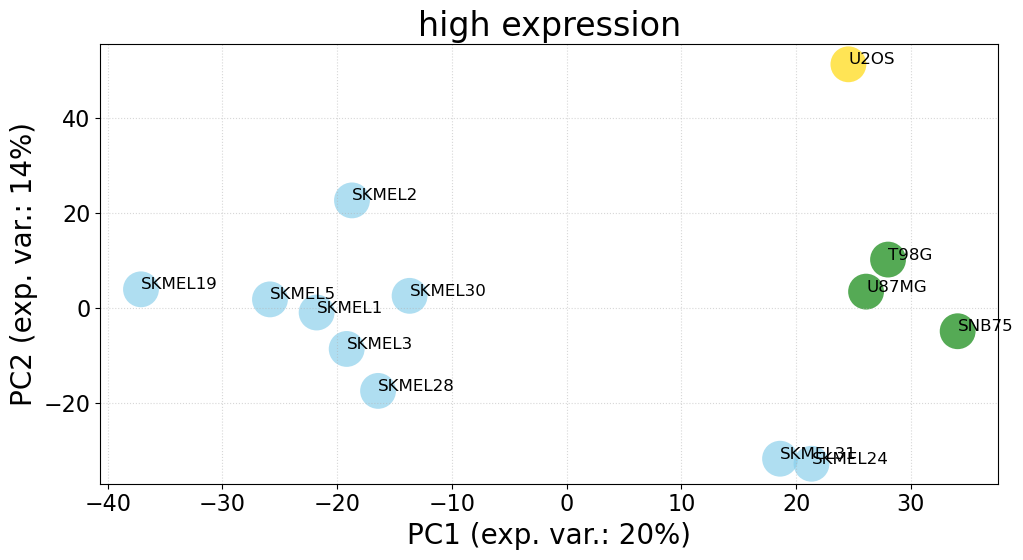

In [16]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

for i in range(len(new)):
    if i == 0:
        the_color = 'gold'
    elif i in [12, 11, 10]:
        the_color = 'green'
    else:
        the_color = 'skyblue'

    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    matplotlib.pyplot.text(new[i,0], new[i,1], cell_line_names_map[expression.columns[i]], fontsize=12)

matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.title('high expression')
matplotlib.pyplot.grid(alpha=0.5, ls=':')
matplotlib.pyplot.tight_layout()

In [17]:
expression

,ACH-000364,ACH-000465,ACH-001190,ACH-000423,ACH-000730,ACH-002005,ACH-000822,ACH-000615,ACH-000810,ACH-000640,ACH-000504,ACH-000571,ACH-000075
TSPAN6 (7105),4.519164,3.656496,4.002703,3.707083,3.877744,3.904002,3.854993,3.364572,3.350497,4.006298,3.676944,2.737687,3.244887
TNMD (64102),0.000000,0.000000,0.056584,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.111031,0.000000,0.000000
DPM1 (8813),6.673698,6.244316,7.097716,7.598797,6.580748,7.257576,5.883376,6.627753,6.390599,6.499049,6.646019,6.742949,7.124535
SCYL3 (57147),2.134221,2.518535,2.718088,2.350497,1.739848,2.341986,2.090853,1.956057,2.395063,1.669027,2.446256,2.304511,1.933573
C1orf112 (55732),4.107688,3.646163,4.610582,4.341274,3.824768,3.534809,3.367371,3.880686,4.472488,3.221877,4.144046,3.716991,3.493135
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ELOA3B (728929),0.000000,0.000000,0.000000,0.356144,0.000000,0.000000,0.000000,0.000000,0.000000,0.056584,0.000000,0.000000,0.000000
NPBWR1 (2831),0.505891,0.014355,0.344828,0.056584,0.000000,0.000000,0.176323,0.056584,0.000000,0.475085,0.056584,0.028569,0.028569
ELOA3D (100506888),0.000000,0.163499,0.000000,0.226509,0.014355,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ELOA3 (162699),0.389567,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.070389,0.000000


In [18]:
z_critical = scipy.stats.norm.ppf(q = 0.975)
print(z_critical)

scipy.stats.norm.sf(1.96)*2

1.959963984540054


0.04999579029644087

In [19]:
all_pvalues = []
all_z = []
count = 0

for gene in list(expression.index):

    # check that it passes 10 tpm at some point
    v = list(expression.loc[gene])
    w = v[:-3]
    if numpy.max(w) >= numpy.log2(10+1):

        # check that first sample is 10 tpm different from median
        tpms = (2**numpy.array(w)) - 1
        a = tpms[0]
        b = numpy.median(tpms[1:])
        if numpy.abs(a - b) > 10:

            # get the zscore and p value
            z = scipy.stats.zscore(w)
            p = scipy.stats.norm.sf(numpy.abs(z[0]))*2
            all_pvalues.append(p)
            all_z.append(z[0])
            if p < 0.05:
                count = count + 1
            

# 
print(len(all_pvalues))
print(max(all_z))
print(scipy.stats.norm.sf(numpy.abs(3))*2)
print(count)

5238
2.9999224074777966
0.002699796063260186
1375


In [20]:
results = statsmodels.stats.multitest.multipletests(all_pvalues, method='fdr_bh', alpha=0.1)
print(min(results[1]))
for i in range(len(results[0])):
    if results[1][i] < 0.1:
        print(i, results[0][i], results[1][i])
    print()

0.1510105390978356























































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































In [21]:
sum(results[0])

0

In [22]:
min(results[1])

0.1510105390978356

In [23]:
#methods = ['bonferroni', 'sidak', 'holm-sidak', 'holm', 'simes-hochberg', 'hommel', 'fdr_bh', 'fdr_by', 'fdr_tsbh', 'fdr_tsbky']
methods = ['bonferroni', 'fdr_bh']

for the_method in methods:
    results = statsmodels.stats.multitest.multipletests(all_pvalues, method=the_method)
    print(the_method)
    for i in range(len(results[0])):
        if results[1][i] < 0.5:
            print(i, results[0][i], results[1][i], sampling_categories[i])
    print()

bonferroni

fdr_bh


NameError: name 'sampling_categories' is not defined

In [ ]:
# plot the distribution of expression
# do a PCA
# consider a z score on genes. for a variablity of at least 10 tpm, with crossing 10 tpm get the z scores and correct p values say how many genes are that from other comparisons
# hen comparing yellow only eight
# consider quantile normalization before any analysis